# 09 — R-GCN link prediction (Task 5, part 2)

**R-GCN** (Schlichtkrull et al. 2018) extends the vanilla GCN with **one learnable weight matrix per edge relation type**.  In Hetionet's CGD walk graph we have several distinct relations:

- `Compound–treats–Disease` (the label we care about — dropped from the training graph)
- `Compound–binds–Gene`, `Compound–resembles–Compound`, `Compound–upregulates–Gene`, ...
- `Gene–interacts–Gene`, `Gene–participates–BiologicalProcess`, ...
- `Disease–associates–Gene`, `Disease–resembles–Disease`, ...

Vanilla GCN (nb08) treats all these as the *same* kind of edge — the walker doesn't know the difference between "drug binds gene" and "disease associates with gene".  R-GCN gives each relation its own weight matrix, so the model can learn *how* to aggregate along each relation differently.

**What this notebook answers**:
1. Does adding edge-type awareness beat vanilla GCN (nb08 AUROC 0.922, AUPRC 0.179)?
2. If yes, by how much?  If no, why not — is the CGD subgraph structurally too simple to benefit?
3. Cost: R-GCN has R× more parameters than GCN (R = number of edge kinds).  Is the accuracy gain worth the extra compute?

## 1 · Setup

In [1]:
from __future__ import annotations
import json, pathlib, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import roc_auc_score, average_precision_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import RGCNConv

from utils import load_hetnet, setup_plot_style
setup_plot_style()

ART   = pathlib.Path("artifacts")
CACHE = pathlib.Path("cache/rgcn"); CACHE.mkdir(parents=True, exist_ok=True)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Device: {device}")


Device: mps


In [2]:
# Locked split
meta  = json.loads((ART / "splits" / "split_meta.json").read_text())
pairs = pd.read_parquet(ART / "splits" / "pairs.parquet")
split = np.load(ART / "splits" / "lr_split.npz")
idx_train, idx_test = split["idx_train"], split["idx_test"]
SEED = int(meta["split_seed"])
y = pairs["y"].to_numpy()

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Pairs: {len(pairs):,} | positives: {int(y.sum())} | test positives: {int(y[idx_test].sum())}")


Pairs: 206,312 | positives: 755 | test positives: 151


## 2 · Build the walk graph — **same as nb08, but keep edge kinds**

The three preprocessing steps are unchanged (C+G+D, drop test CtD, hub-correct 20 genes, LCC). Only difference: each edge now carries a `kind` attribute, and we map `kind` strings to integer relation IDs so `RGCNConv` can index its per-relation weight matrix.

In [3]:
HUB_K = 20
KEEP_KINDS = {"Compound", "Gene", "Disease"}

t0 = time.time()
hetnet = load_hetnet()
print(f"Loaded hetnet in {time.time() - t0:.1f}s")

G = nx.Graph()
for n in hetnet["nodes"]:
    if n["kind"] in KEEP_KINDS:
        G.add_node((n["kind"], n["identifier"]), kind=n["kind"], name=n["name"])
kept = set(G.nodes())
for e in hetnet["edges"]:
    u = tuple(e["source_id"]); v = tuple(e["target_id"])
    if u in kept and v in kept:
        G.add_edge(u, v, kind=e["kind"])

pos_mask = y == 1
test_mask = np.zeros(len(pairs), dtype=bool); test_mask[idx_test] = True
test_positives  = pairs.loc[pos_mask & test_mask,  ["compound", "disease"]]
train_positives = pairs.loc[pos_mask & ~test_mask, ["compound", "disease"]]

dropped = 0
for c, d in test_positives.itertuples(index=False):
    u, v = ("Compound", c), ("Disease", d)
    if G.has_edge(u, v):
        G.remove_edge(u, v); dropped += 1

gene_deg = sorted(((n, deg) for n, deg in G.degree() if n[0] == "Gene"), key=lambda x: -x[1])
G.remove_nodes_from([n for n, _ in gene_deg[:HUB_K]])
lcc_nodes = max(nx.connected_components(G), key=len)
G = G.subgraph(lcc_nodes).copy()

print(f"Walk graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges, "
      f"{dropped} test CtD edges dropped.")

# Count edge kinds
edge_kinds = pd.Series([d["kind"] for _, _, d in G.edges(data=True)]).value_counts()
print(f"\nEdge kinds in walk graph:")
print(edge_kinds)


Loaded hetnet in 11.7s


Walk graph: 19,683 nodes, 525,174 edges, 151 test CtD edges dropped.



Edge kinds in walk graph:
regulates        245657
interacts        132247
covaries          61504
downregulates     27669
upregulates       26134
associates        12440
binds             11505
resembles          7024
treats              604
palliates           390
Name: count, dtype: int64


In [4]:
# Map (kind, id) -> int; and edge kind string -> int
node_list = list(G.nodes())
node_idx  = {n: i for i, n in enumerate(node_list)}
num_nodes = len(node_list)

relation_names = sorted({d["kind"] for _, _, d in G.edges(data=True)})
rel_idx = {k: i for i, k in enumerate(relation_names)}
num_relations = len(relation_names)
print(f"num_nodes={num_nodes:,}, num_relations={num_relations}")
for k, i in rel_idx.items():
    print(f"  {i:2d} · {k}")

# Directed edge_index + edge_type
src, dst, rel = [], [], []
for u, v, edata in G.edges(data=True):
    r = rel_idx[edata["kind"]]
    src.extend([node_idx[u], node_idx[v]])
    dst.extend([node_idx[v], node_idx[u]])
    rel.extend([r, r])

edge_index = torch.tensor([src, dst], dtype=torch.long)
edge_type  = torch.tensor(rel, dtype=torch.long)
print(f"\nedge_index: {tuple(edge_index.shape)}")
print(f"edge_type : {tuple(edge_type.shape)}  (values in [0, {num_relations - 1}])")


num_nodes=19,683, num_relations=10
   0 · associates
   1 · binds
   2 · covaries
   3 · downregulates
   4 · interacts
   5 · palliates
   6 · regulates
   7 · resembles
   8 · treats
   9 · upregulates



edge_index: (2, 1050348)
edge_type : (1050348,)  (values in [0, 9])


## 3 · Label edge tensors

Same convention as nb08: `train_pos_edges` for supervision, `eval_edges` for scoring the whole nb04 pair universe.

In [5]:
compound_ids_in_G = {n[1]: node_idx[n] for n in node_list if n[0] == "Compound"}
disease_ids_in_G  = {n[1]: node_idx[n] for n in node_list if n[0] == "Disease"}

def to_edge_tensor(df):
    us, vs, mask = [], [], []
    for c, d in df[["compound", "disease"]].itertuples(index=False):
        u = compound_ids_in_G.get(c, -1)
        v = disease_ids_in_G.get(d, -1)
        if u >= 0 and v >= 0:
            us.append(u); vs.append(v); mask.append(True)
        else:
            us.append(0); vs.append(0); mask.append(False)
    return (torch.tensor([us, vs], dtype=torch.long),
            torch.tensor(mask, dtype=torch.bool))

train_pos_edges, _         = to_edge_tensor(train_positives)
eval_edges,      eval_have = to_edge_tensor(pairs)
print(f"Training positives : {train_pos_edges.size(1)}")
print(f"Eval pairs covered : {int(eval_have.sum())}/{len(pairs)}")


Training positives : 604
Eval pairs covered : 206312/206312


## 4 · The R-GCN model

`RGCNConv` implements $h_v^{(l+1)} = \sigma\!\left( \sum_{r \in R} \frac{1}{|N_v^r|} \sum_{u \in N_v^r} W_r^{(l)} h_u^{(l)} + W_0^{(l)} h_v^{(l)} \right)$ — one learnable $W_r$ per relation.  We use `num_bases=8` (matrix-decomposition regularizer that shares components across relations) to keep the parameter count in check when relation count grows.

In [6]:
HIDDEN_DIM = 64
NUM_BASES  = 8      # basis-decomposition regularizer
DROPOUT    = 0.2
LR         = 0.01
EPOCHS     = 200
NEG_RATIO  = 1


class RGCNLinkPredictor(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim, num_bases, dropout):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        self.conv1 = RGCNConv(hidden_dim, hidden_dim, num_relations, num_bases=num_bases)
        self.conv2 = RGCNConv(hidden_dim, hidden_dim, num_relations, num_bases=num_bases)
        self.dropout = dropout

    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight
        x = F.relu(self.conv1(x, edge_index, edge_type))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index, edge_type)
        return x

    @staticmethod
    def decode(z, edges):
        return (z[edges[0]] * z[edges[1]]).sum(dim=-1)


model = RGCNLinkPredictor(num_nodes, num_relations, HIDDEN_DIM, NUM_BASES, DROPOUT).to(device)
edge_index_dev = edge_index.to(device)
edge_type_dev  = edge_type.to(device)
train_pos_dev  = train_pos_edges.to(device)
eval_edges_dev = eval_edges.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: 2-layer R-GCN, hidden={HIDDEN_DIM}, relations={num_relations}, "
      f"num_bases={NUM_BASES}, params={n_params:,}")


Model: 2-layer R-GCN, hidden=64, relations=10, num_bases=8, params=1,333,728


## 5 · Training

In [7]:
train_pos_pairs = set(zip(train_pos_edges[0].tolist(), train_pos_edges[1].tolist()))
compound_indices = np.array([i for i, n in enumerate(node_list) if n[0] == "Compound"])
disease_indices  = np.array([i for i, n in enumerate(node_list) if n[0] == "Disease"])
rng = np.random.default_rng(SEED)


def sample_negative_edges(n_samples: int) -> torch.Tensor:
    us, vs = [], []
    tries = 0
    while len(us) < n_samples and tries < n_samples * 10:
        c = int(compound_indices[rng.integers(0, len(compound_indices))])
        d = int(disease_indices[rng.integers(0, len(disease_indices))])
        if (c, d) not in train_pos_pairs:
            us.append(c); vs.append(d)
        tries += 1
    return torch.tensor([us, vs], dtype=torch.long)


optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_history = []
auroc_history = []

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    n_pos = train_pos_dev.size(1)
    neg_edges = sample_negative_edges(n_pos * NEG_RATIO).to(device)

    z = model.encode(edge_index_dev, edge_type_dev)
    pos_scores = model.decode(z, train_pos_dev)
    neg_scores = model.decode(z, neg_edges)

    scores = torch.cat([pos_scores, neg_scores])
    labels = torch.cat([torch.ones_like(pos_scores),
                        torch.zeros_like(neg_scores)])
    loss = F.binary_cross_entropy_with_logits(scores, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(float(loss.item()))

    if epoch % 10 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            z_eval = model.encode(edge_index_dev, edge_type_dev)
            scores_all = model.decode(z_eval, eval_edges_dev).cpu().numpy()
            scores_all[~eval_have.numpy()] = -1e9
            auroc = roc_auc_score(y[idx_test], scores_all[idx_test])
        auroc_history.append((epoch, auroc))
        print(f"  epoch {epoch:3d}  loss={loss.item():.4f}  test AUROC={auroc:.4f}")

train_seconds = time.time() - t0
print(f"\nTraining done in {train_seconds:.1f}s")


  epoch   1  loss=0.6921  test AUROC=0.8688


  epoch  10  loss=0.1256  test AUROC=0.8929


  epoch  20  loss=0.0813  test AUROC=0.9076


  epoch  30  loss=0.0646  test AUROC=0.8927


  epoch  40  loss=0.0502  test AUROC=0.8877


...

  epoch 160  loss=0.0333  test AUROC=0.9277


  epoch 170  loss=0.0407  test AUROC=0.9167


  epoch 180  loss=0.0187  test AUROC=0.9093


  epoch 190  loss=0.0212  test AUROC=0.9190


  epoch 200  loss=0.0215  test AUROC=0.9172

Training done in 411.1s


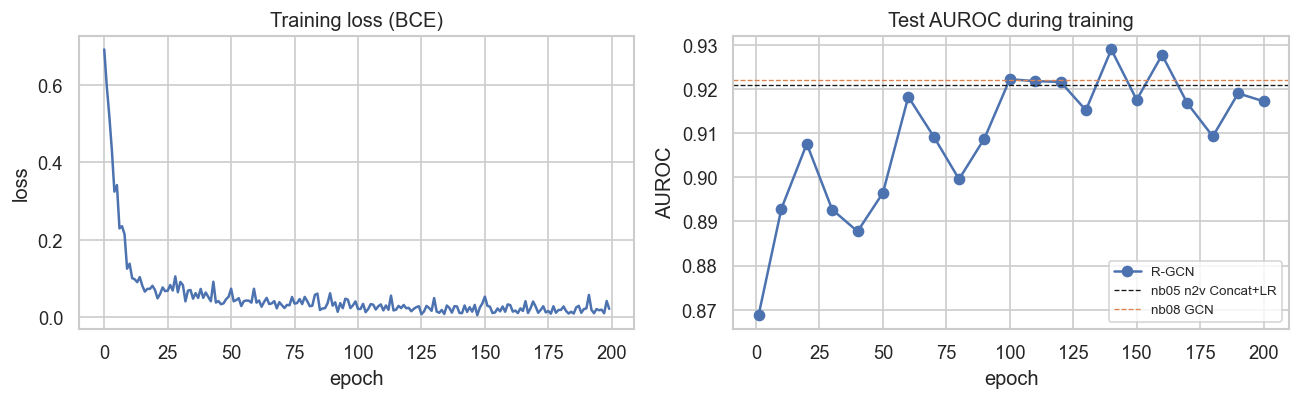

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(loss_history)
axes[0].set(title="Training loss (BCE)", xlabel="epoch", ylabel="loss")
ep, ar = zip(*auroc_history)
axes[1].plot(ep, ar, marker="o", label="R-GCN")
axes[1].axhline(0.921, color="k", ls="--", lw=0.8, label="nb05 n2v Concat+LR")
axes[1].axhline(0.922, color="C1", ls="--", lw=0.8, label="nb08 GCN")
axes[1].set(title="Test AUROC during training", xlabel="epoch", ylabel="AUROC")
axes[1].legend(fontsize=8)
plt.tight_layout()


## 6 · Final evaluation + headline table

In [9]:
def bootstrap_ci(y_true, y_score, metric, B=500, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    vals = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n, n)
        if y_true[idx].sum() == 0:
            vals[b] = np.nan; continue
        vals[b] = metric(y_true[idx], y_score[idx])
    vals = vals[~np.isnan(vals)]
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


model.eval()
with torch.no_grad():
    z_final = model.encode(edge_index_dev, edge_type_dev)
    score_rgcn = model.decode(z_final, eval_edges_dev).cpu().numpy()
    score_rgcn[~eval_have.numpy()] = -1e9

y_test = y[idx_test]
s_test = score_rgcn[idx_test]
auroc = roc_auc_score(y_test, s_test)
auprc = average_precision_score(y_test, s_test)
lo_roc, hi_roc = bootstrap_ci(y_test, s_test, roc_auc_score)
lo_pr,  hi_pr  = bootstrap_ci(y_test, s_test, average_precision_score)

prior = float(y_test.mean())
order = np.argsort(-s_test)
yy = y_test[order]
topk = {K: int(yy[:K].sum()) / K for K in [10, 50, 100, 500, 1000]}

# Compare with nb05 (Node2Vec) + nb08 (GCN)
n2v_meta = json.loads((ART / "predictions" / "node2vec_meta.json").read_text())
gcn_meta = json.loads((ART / "predictions" / "gcn_meta.json").read_text())

rows = []
for r in n2v_meta["results"]:
    rows.append({"method": r["method"], "AUROC": round(r["AUROC"], 4), "AUPRC": round(r["AUPRC"], 4)})
rows.append({
    "method": "gcn · 2-layer (nb08)",
    "AUROC": gcn_meta["results"]["AUROC"], "AUPRC": gcn_meta["results"]["AUPRC"],
})
rows.append({
    "method": "rgcn · 2-layer (this)",
    "AUROC": round(auroc, 4), "AUPRC": round(auprc, 4),
})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

print(f"\nR-GCN AUROC 95% CI: [{lo_roc:.3f}, {hi_roc:.3f}]")
print(f"R-GCN AUPRC 95% CI: [{lo_pr:.4f}, {hi_pr:.4f}]")
print(f"\nTop-K precision (random baseline {prior:.4%}):")
for K, p in topk.items():
    print(f"  P@{K:<4d} = {p:.4f}  ({p/prior:.1f}x random)")

print(f"\nGCN vs R-GCN top-K comparison:")
for K in [10, 50, 100, 500, 1000]:
    gk = gcn_meta["results"]["top_k"][str(K)]
    print(f"  P@{K:<4d} · GCN={gk:.4f} · R-GCN={topk[K]:.4f} · Δ={topk[K]-gk:+.4f}")


                        method  AUROC  AUPRC
      node2vec + Hadamard + LR 0.8594 0.0227
      node2vec + Concat   + LR 0.9209 0.0310
             node2vec + Cosine 0.7807 0.0176
spectral + Concat   + LR (nb4) 0.6811 0.0097
spectral + Cosine        (nb4) 0.6215 0.0058
          gcn · 2-layer (nb08) 0.9218 0.1787
         rgcn · 2-layer (this) 0.9172 0.1839

R-GCN AUROC 95% CI: [0.896, 0.938]
R-GCN AUPRC 95% CI: [0.1328, 0.2593]

Top-K precision (random baseline 0.3659%):
  P@10   = 0.4000  (109.3x random)
  P@50   = 0.4400  (120.2x random)
  P@100  = 0.3600  (98.4x random)
  P@500  = 0.1340  (36.6x random)
  P@1000 = 0.0800  (21.9x random)

GCN vs R-GCN top-K comparison:
  P@10   · GCN=0.7000 · R-GCN=0.4000 · Δ=-0.3000
  P@50   · GCN=0.4200 · R-GCN=0.4400 · Δ=+0.0200
  P@100  · GCN=0.2800 · R-GCN=0.3600 · Δ=+0.0800
  P@500  · GCN=0.1300 · R-GCN=0.1340 · Δ=+0.0040
  P@1000 · GCN=0.0830 · R-GCN=0.0800 · Δ=-0.0030


## 7 · Ablation reflection

Compare the *design deltas* between the three neural approaches:

| Model | Edge-type aware? | End-to-end supervised? | Params (approx) |
|---|---|---|---|
| Node2Vec (nb05) | No | No (2-stage) | just the embedding matrix |
| GCN (nb08)      | No | **Yes**       | embedding + 2 × (d²) |
| R-GCN (nb09)    | **Yes** | **Yes**   | embedding + 2 × (num_bases × d²) + 2 × (R × num_bases) |

If **R-GCN ≫ GCN**: edge-type awareness matters — build on this direction.
If **R-GCN ≈ GCN**: the gain in nb08 was mostly from end-to-end supervision, not from edge types. Then next steps should look at *decoder complexity* (bilinear / MLP) or *sampling strategy* (harder negatives) rather than more relation-aware architectures.

## 8 · Persist

In [10]:
out = pairs[["compound", "disease", "y"]].copy()
out["score_rgcn"] = score_rgcn
out["in_test"]    = test_mask
out.to_parquet(ART / "predictions" / "rgcn.parquet")

meta_rgcn = {
    "method": "rgcn",
    "library": f"torch {torch.__version__} + torch_geometric",
    "config": {
        "layers": 2, "hidden_dim": HIDDEN_DIM, "num_bases": NUM_BASES,
        "dropout": DROPOUT, "lr": LR, "epochs": EPOCHS, "neg_ratio": NEG_RATIO,
        "hub_K": HUB_K, "seed": SEED, "device": str(device),
        "train_seconds": round(train_seconds, 1),
        "num_relations": int(num_relations),
        "relation_names": relation_names,
    },
    "walk_graph": {
        "kinds_kept": sorted(KEEP_KINDS),
        "n_nodes": int(num_nodes),
        "n_edges_directed": int(edge_index.size(1)),
        "test_ctd_edges_removed": int(dropped),
        "coverage": float(eval_have.float().mean()),
    },
    "results": {
        "AUROC": round(auroc, 4),
        "AUROC_95%": [round(lo_roc, 4), round(hi_roc, 4)],
        "AUPRC": round(auprc, 4),
        "AUPRC_95%": [round(lo_pr, 4), round(hi_pr, 4)],
        "top_k": {str(K): round(v, 4) for K, v in topk.items()},
        "lift_vs_random": {str(K): round(v / prior, 1) for K, v in topk.items()},
    },
    "training_curve": {
        "loss_last10": [round(x, 4) for x in loss_history[-10:]],
        "auroc_history": [(e, round(a, 4)) for e, a in auroc_history],
    },
    "compared_with": {
        "gcn":  gcn_meta["results"]["AUROC"],
        **{r["method"]: r["AUROC"] for r in n2v_meta["results"]},
    },
}
(ART / "predictions" / "rgcn_meta.json").write_text(json.dumps(meta_rgcn, indent=2, default=str))
print("Wrote:")
print("  artifacts/predictions/rgcn.parquet")
print("  artifacts/predictions/rgcn_meta.json")


Wrote:
  artifacts/predictions/rgcn.parquet
  artifacts/predictions/rgcn_meta.json
